In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from nflows.distributions.normal import ConditionalDiagonalNormal
from nflows.flows.base import Flow
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation

def find_repo_root(start: Path = Path.cwd()) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / ".git").exists():
            return parent
    return start  

repo_root = find_repo_root()
os.chdir(repo_root)

In [2]:
from src.core.storage import storage

# load data
theta, x = storage.load_simulations("test_1_cov_binned.pt")
print(f"Theta shape: {theta.shape}")  
print(f"X shape: {x.shape}")    

/home/julian/miniconda3/envs/cobaya_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Theta shape: torch.Size([25000, 5])
X shape: torch.Size([25000, 74])


In [3]:
# normalize data for training
# theta and x are normalized to mean 0 and std 1
theta_mean = theta.mean(dim=0)
theta_std = theta.std(dim=0)
x_mean = x.mean(dim=0)
x_std = x.std(dim=0)
theta_norm = (theta - theta_mean) / theta_std
x_norm = (x - x_mean) / x_std
print(f"Theta normalized mean: {theta_norm.mean(dim=0)}")
print(f"Theta normalized std: {theta_norm.std(dim=0)}")

Theta normalized mean: tensor([-4.3434e-07,  1.3244e-06, -9.8409e-05, -1.2661e-05,  3.8354e-06])
Theta normalized std: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [4]:
# setup the flow (maf with 5 layers):
# a flow is a transformation of a base distribution (e.g. normal) into a target 
# distribution (e.g. the posterior), base distribution is a conditional diagonal 
# normal (conditioned on the data x), each layer is a combination of a permutation 
# and a masked affine transformation
num_layers = 5
base_dist = ConditionalDiagonalNormal(shape=[5], context_encoder=nn.Linear(74, 10))
transforms = []
for _ in range(num_layers):
    transforms.append(ReversePermutation(features=5))
    transforms.append(MaskedAffineAutoregressiveTransform(
        features=5, 
        hidden_features=32, 
        context_features=74)
    )
transform = CompositeTransform(transforms)
flow = Flow(transform, base_dist)
optimizer = optim.Adam(flow.parameters(), lr=1e-4)  

Theta true: [0.02212 0.1206  1.04077 3.04    0.9626 ]
X obs shape: torch.Size([74])
X obs normalized mean: 0.0024
Iteration 500, Loss: 4.3570
Iteration 1000, Loss: 1.6786

=== Generando gráfico en iteración 1000 ===


<Figure size 3000x3000 with 0 Axes>

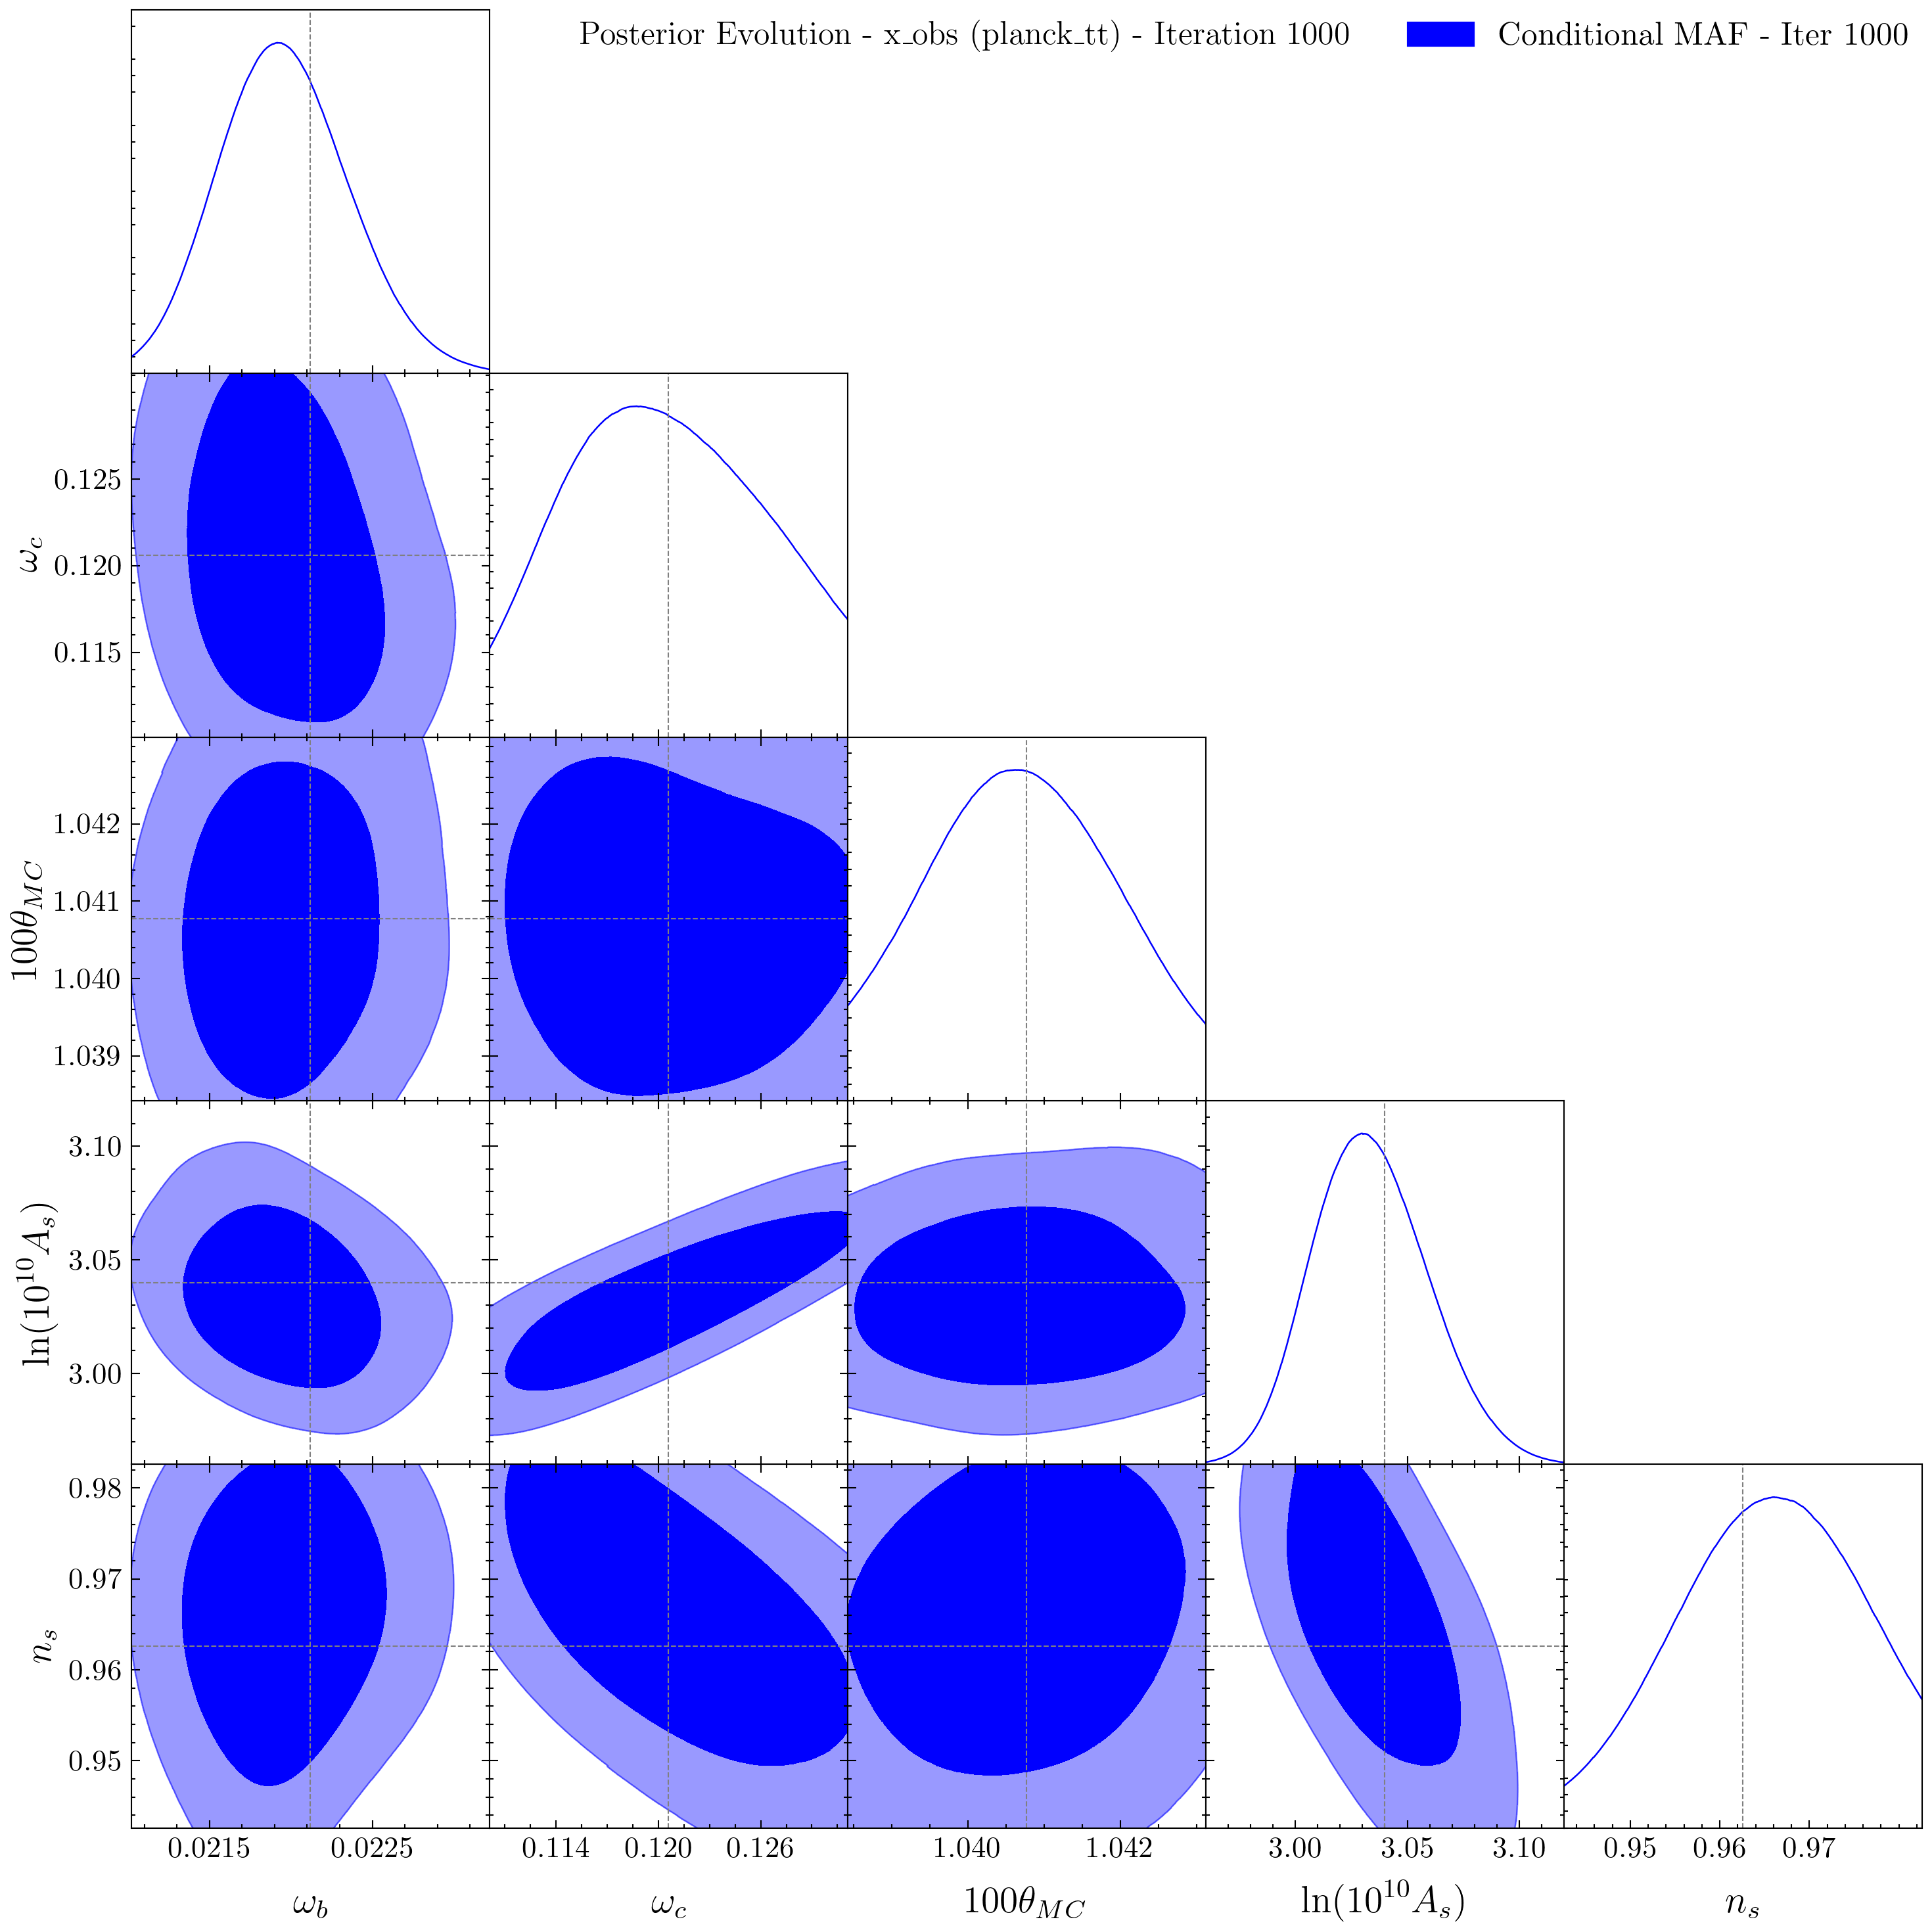

Iteration 1500, Loss: 0.8195
Iteration 2000, Loss: -0.0631

=== Generando gráfico en iteración 2000 ===


<Figure size 3000x3000 with 0 Axes>

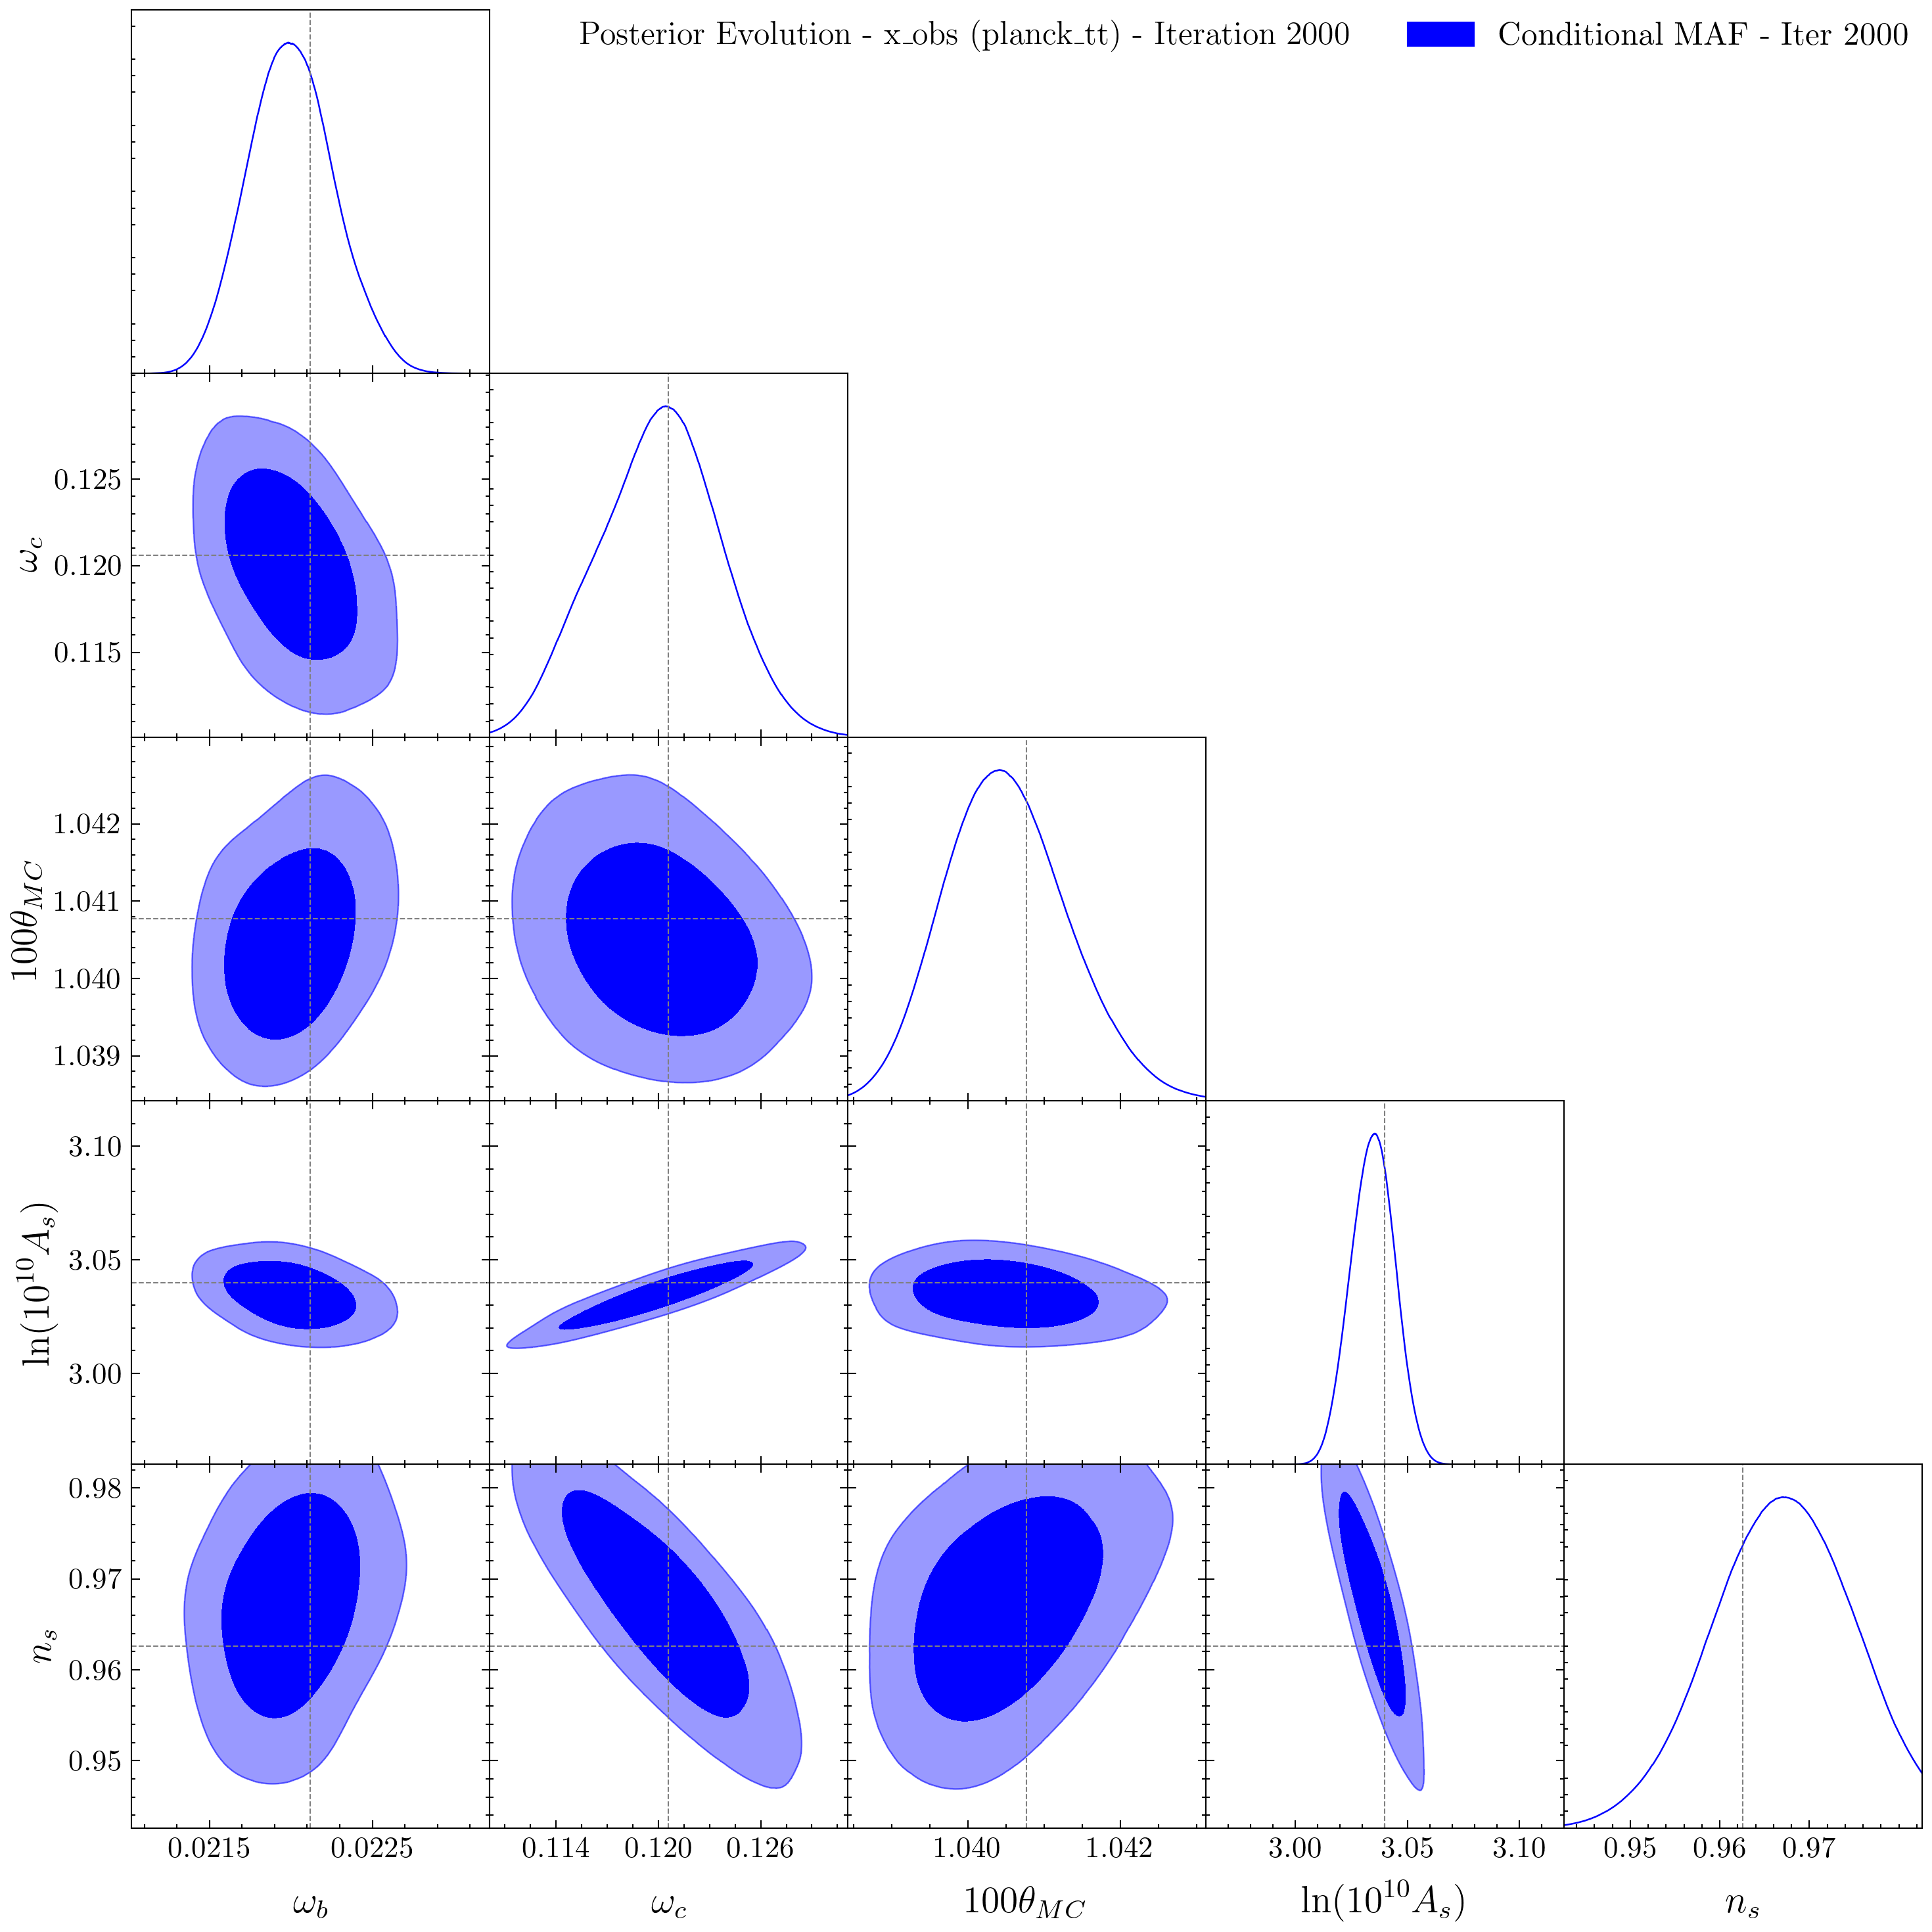

Iteration 2500, Loss: -0.6556
Iteration 3000, Loss: -1.0418

=== Generando gráfico en iteración 3000 ===


<Figure size 3000x3000 with 0 Axes>

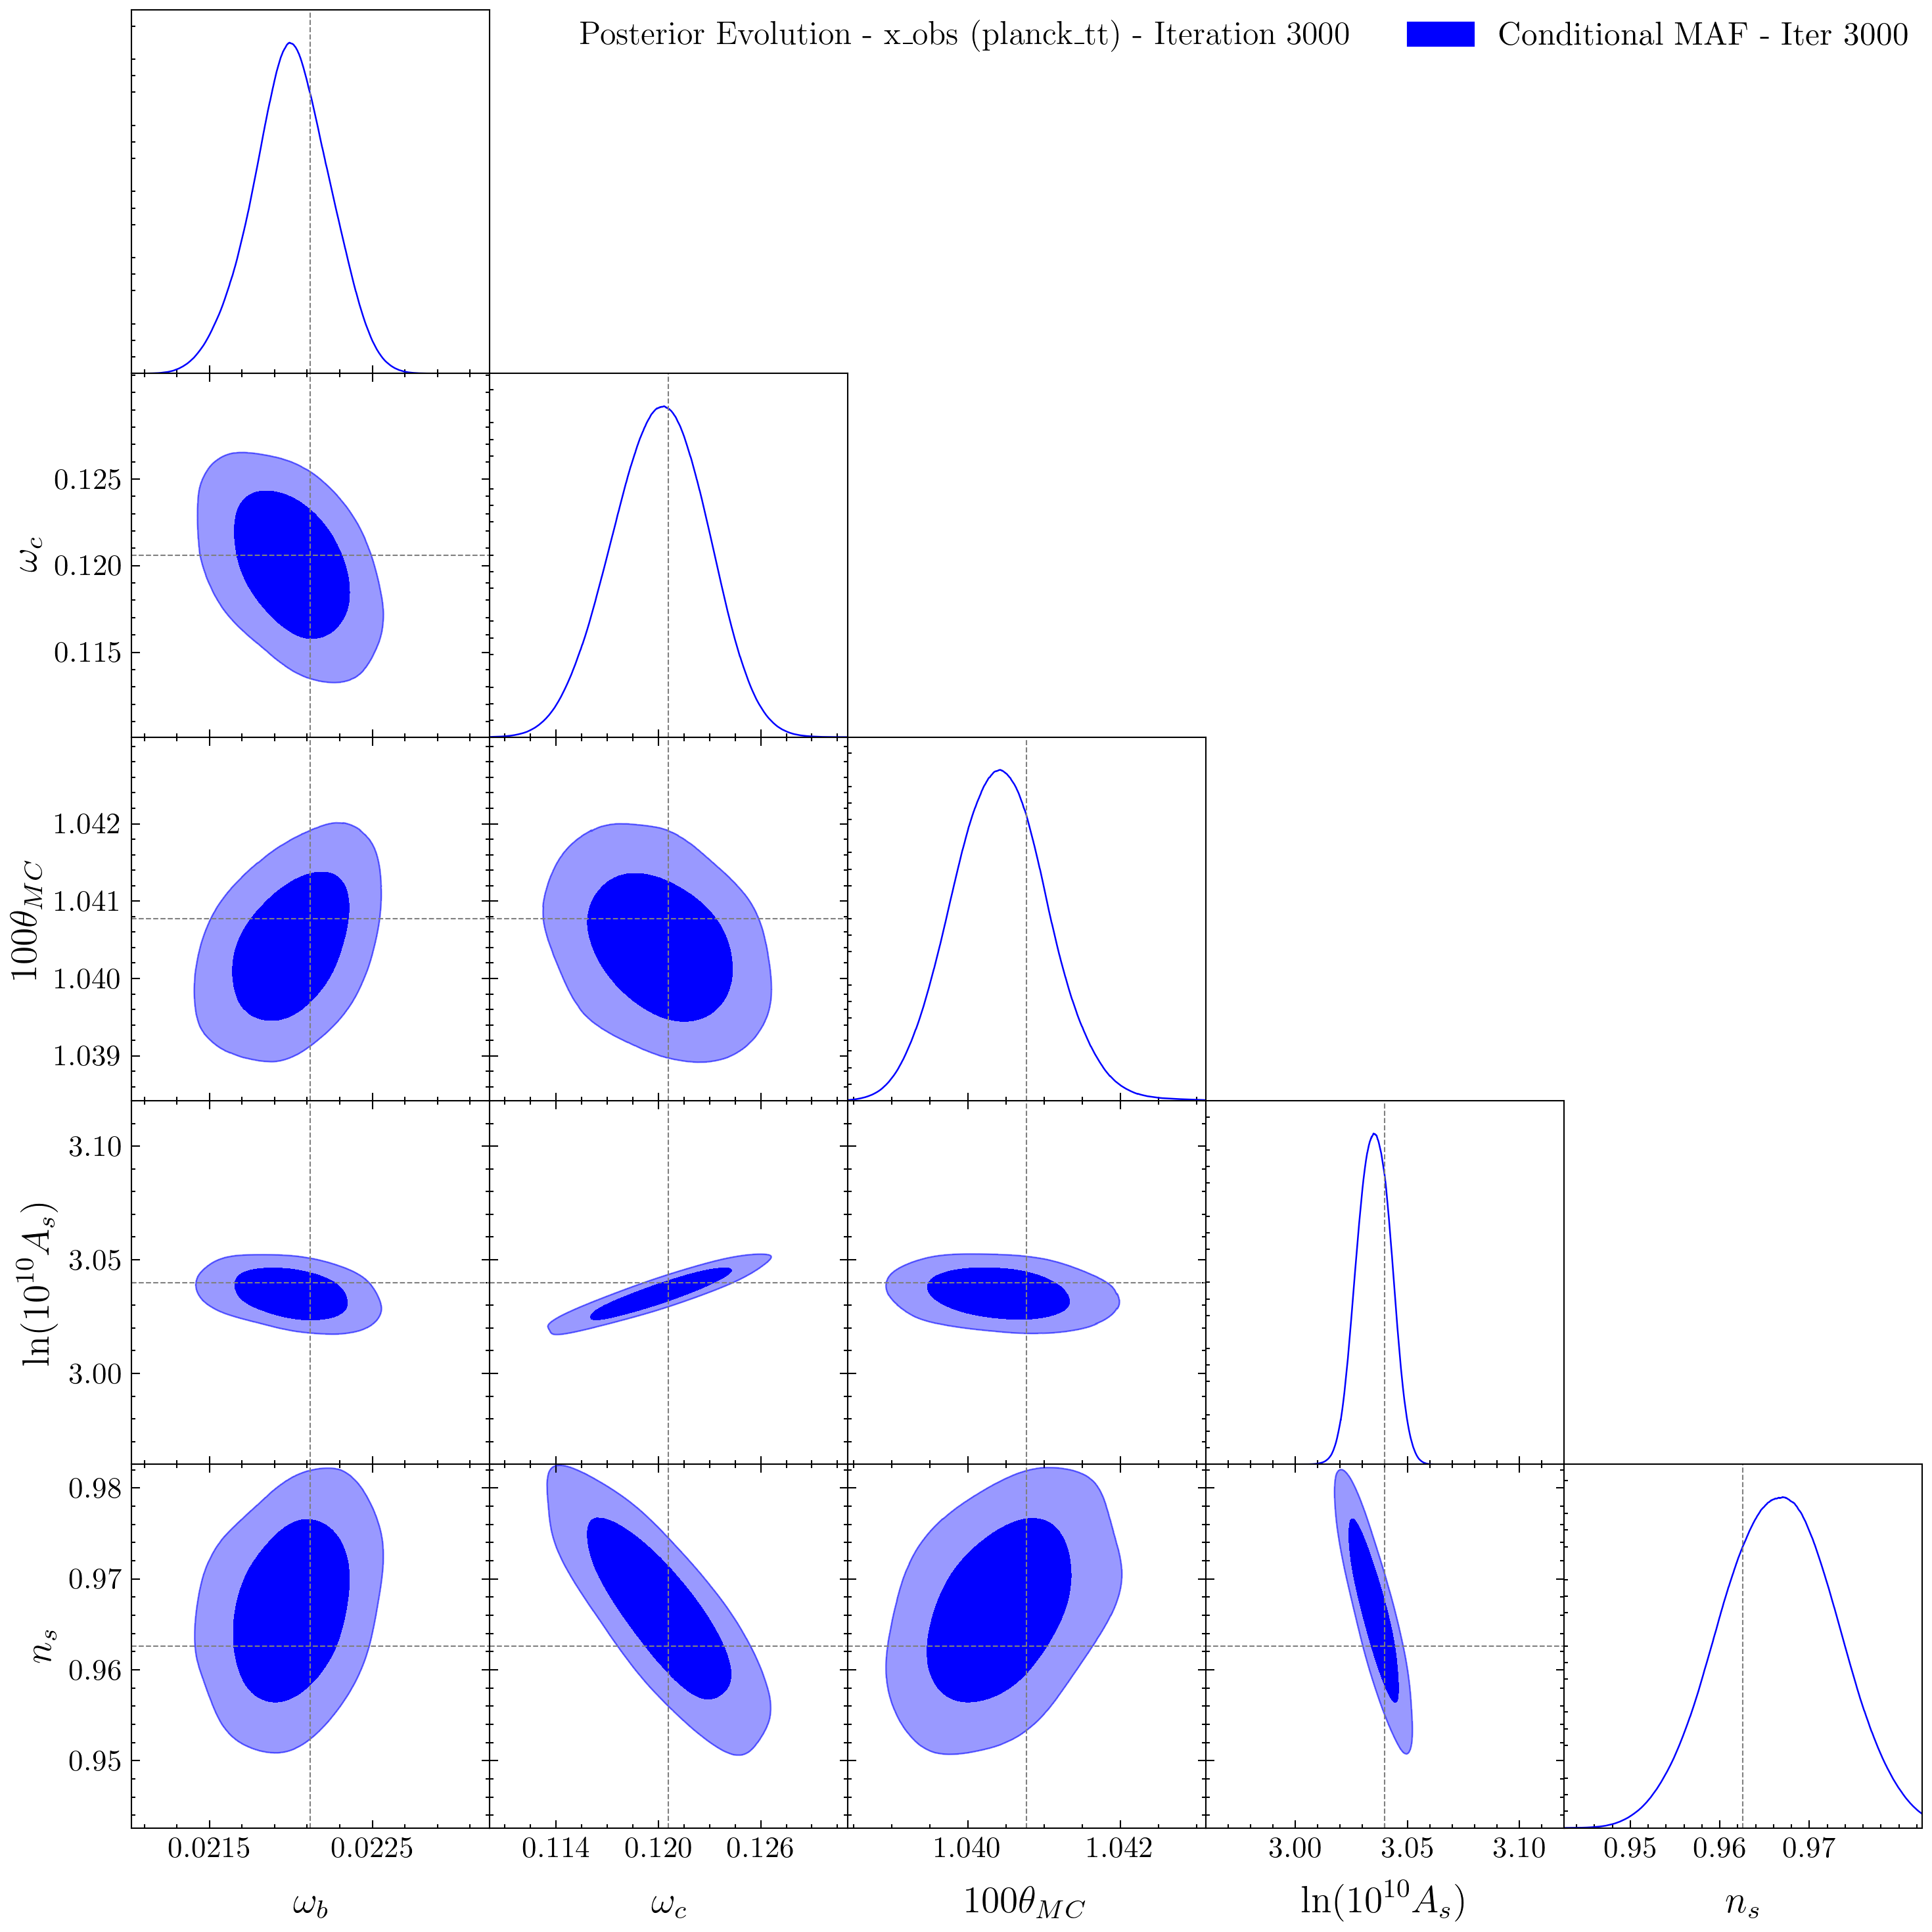

Iteration 3500, Loss: -0.8291
Iteration 4000, Loss: -0.8448

=== Generando gráfico en iteración 4000 ===


<Figure size 3000x3000 with 0 Axes>

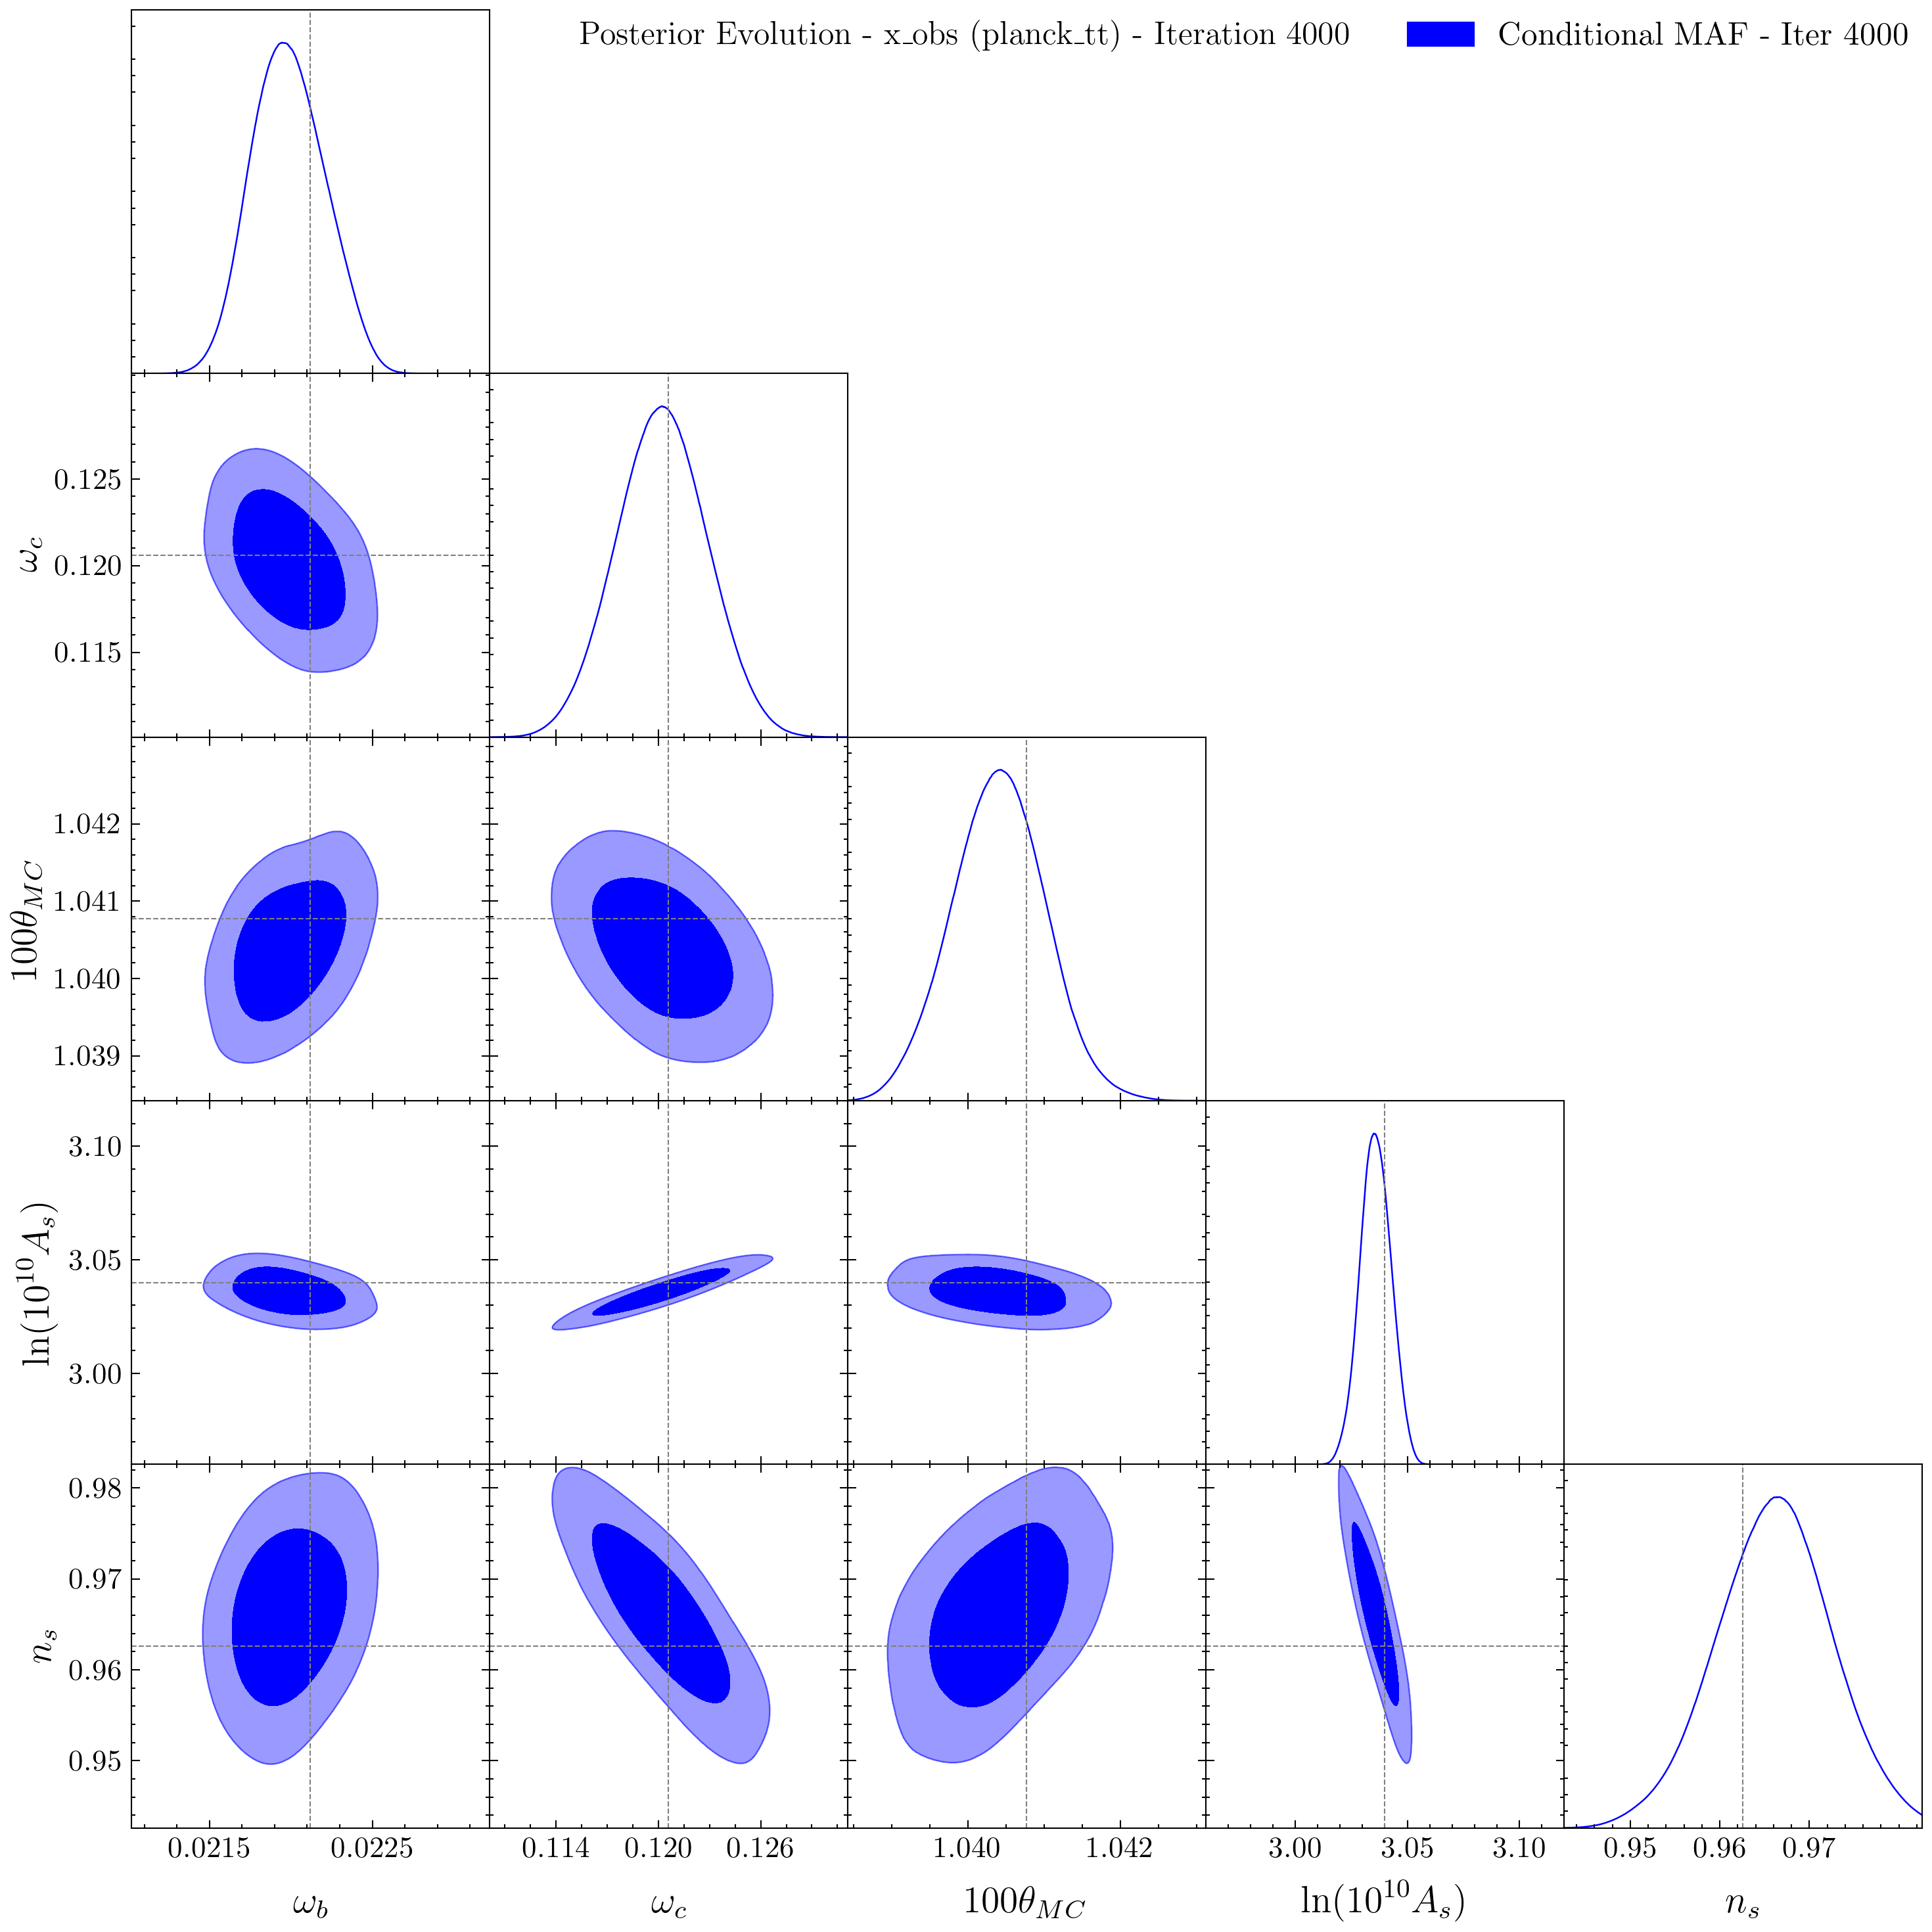

Iteration 4500, Loss: -1.2658
Iteration 5000, Loss: -1.2053

=== Generando gráfico en iteración 5000 ===


<Figure size 3000x3000 with 0 Axes>

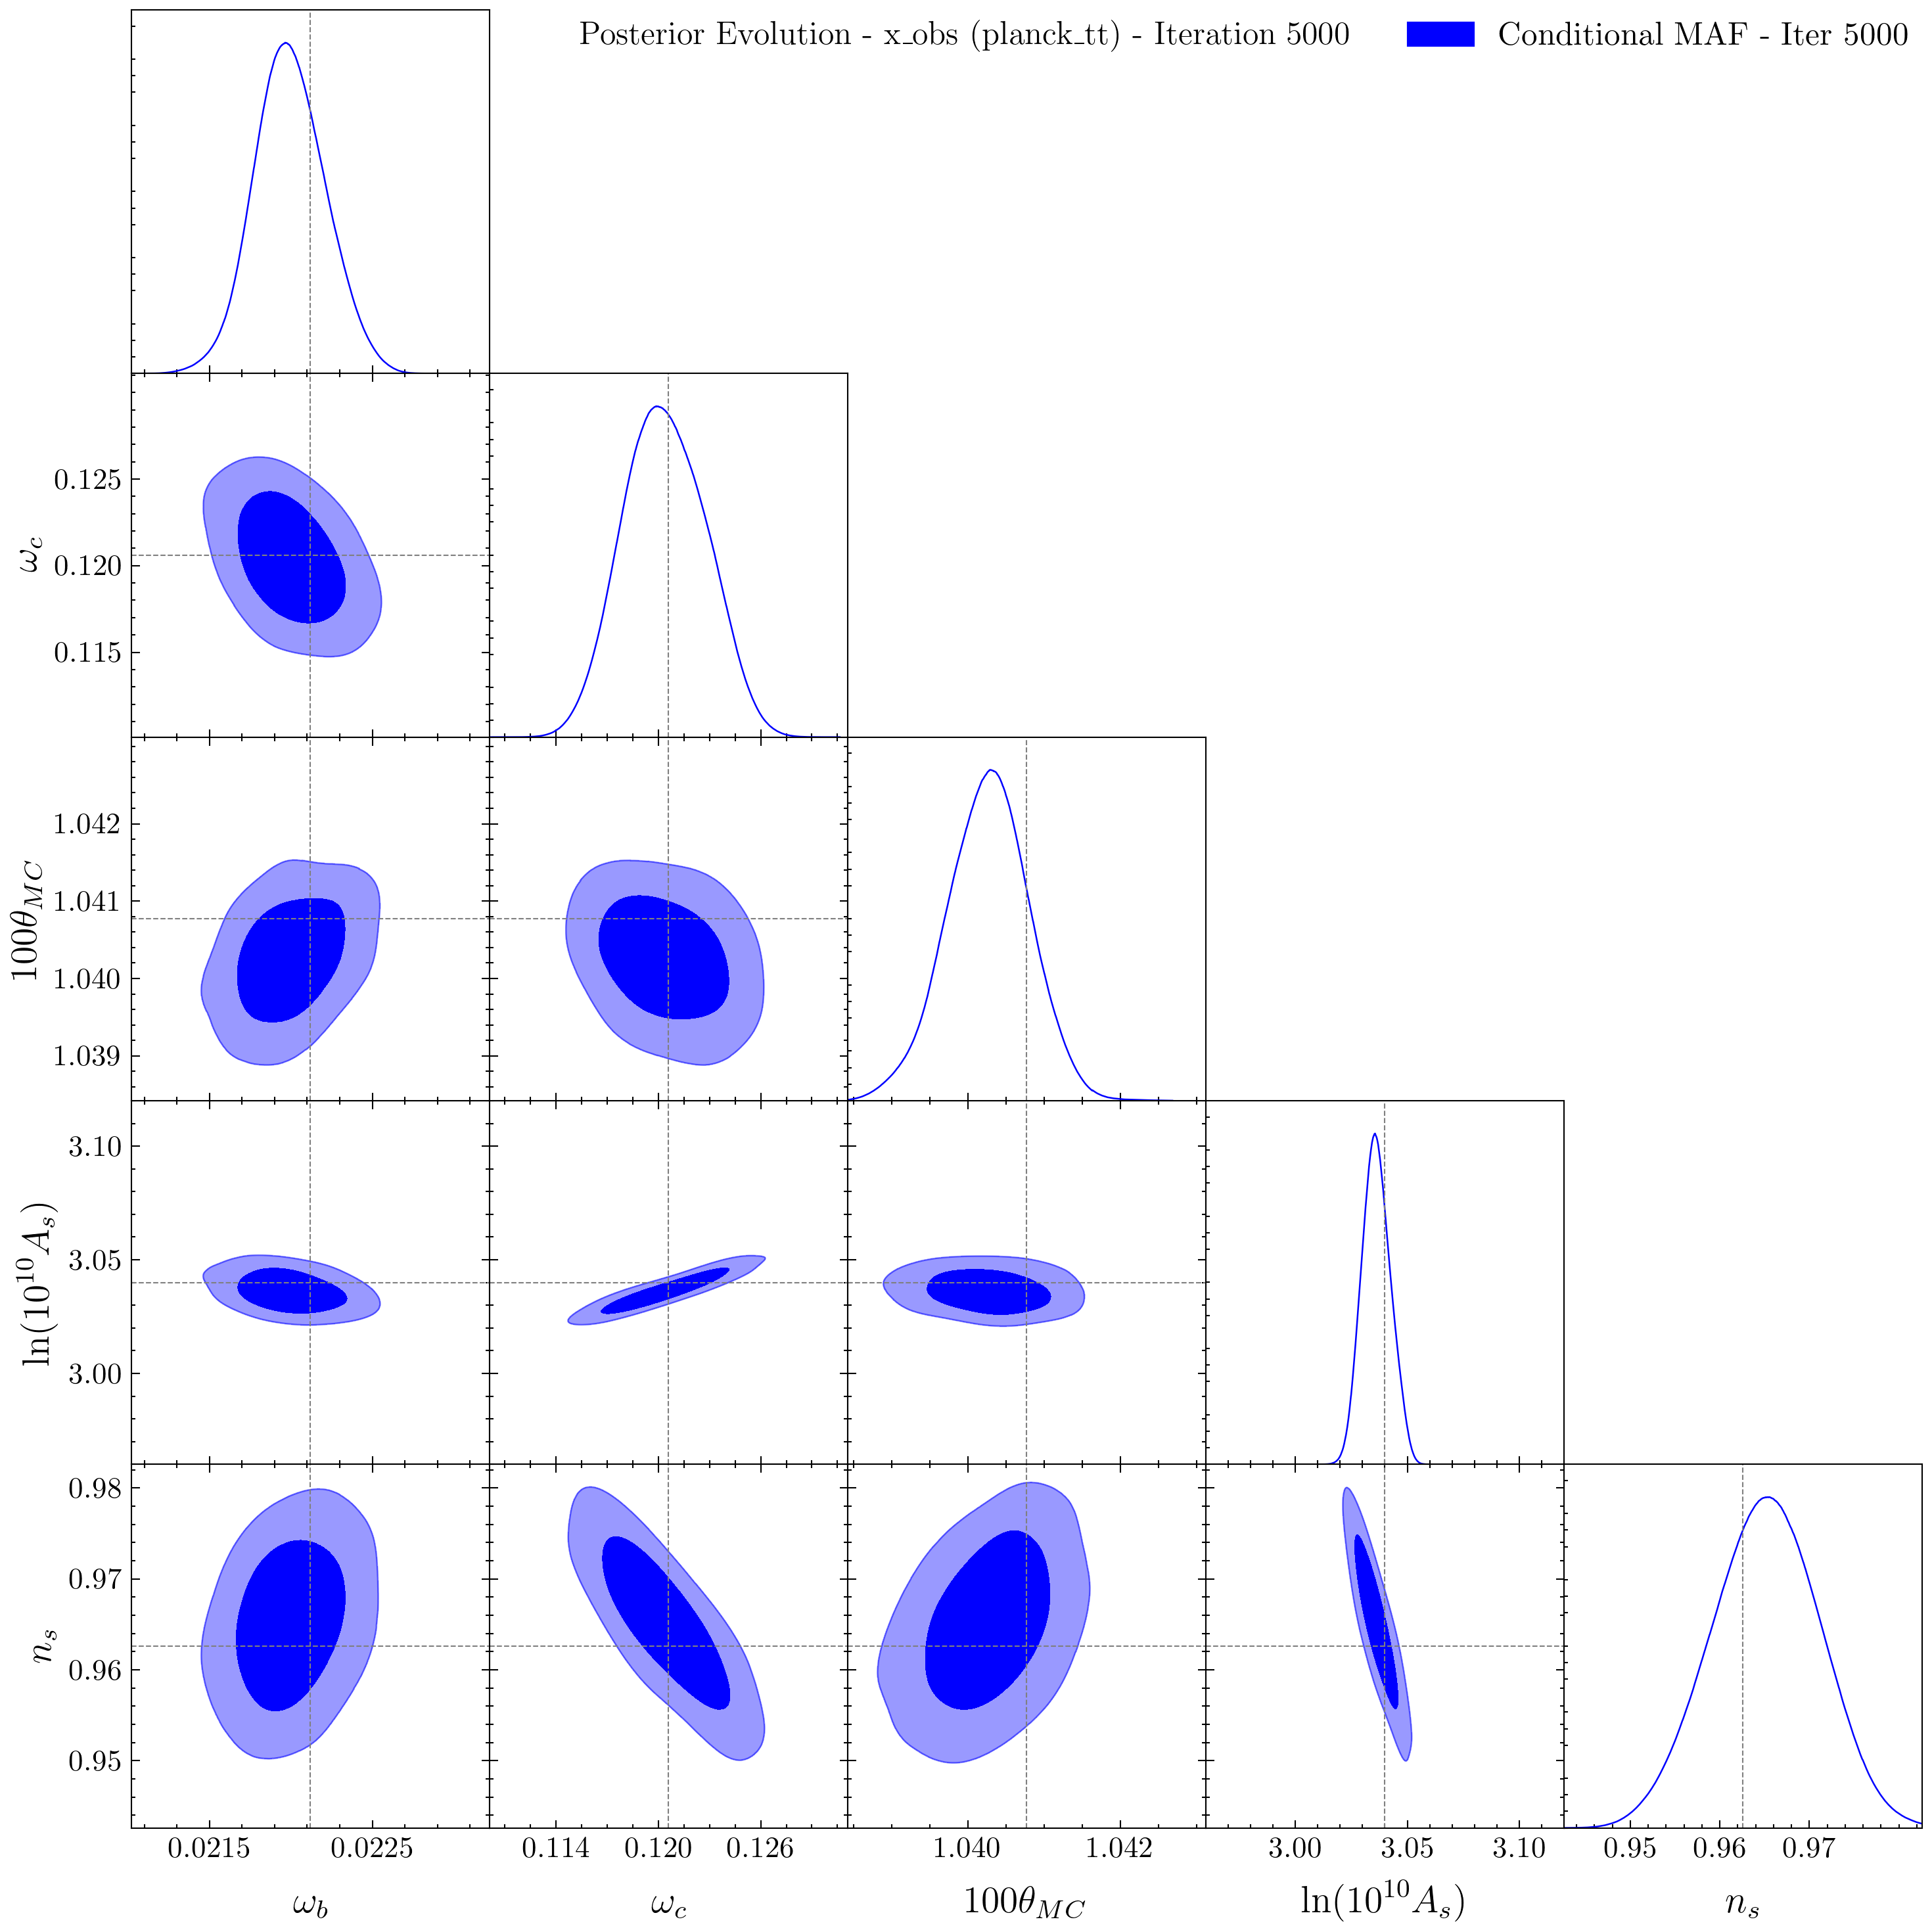

In [5]:
from scripts.plot_ppc import plot_and_save_ppc
from src.simulation.api import simulate_observation

# set the number of iterations (number of times the flow will be trained) and the number 
# of samples (number of simulated observations)
num_iter = 5000
n_samples = len(theta)

# set the number of iterations to plot for the ppc of each iteration 
# also set the mock observation that will be used for the ppc
plot_iterations = [0, 1000, 2000, 3000, 4000, 5000]  
current_iter = 0
theta_true = torch.tensor([
    0.02212,    # ombh2
    0.1206,     # omch2
    1.04077,    # theta_MC_100
    3.04,       # ln_10_10_As
    0.9626      # ns
])
x_obs = simulate_observation(
    theta_true=theta_true,
    observation_type="planck_tt",
    seed=0
)
x_obs_norm = (x_obs - x_mean) / x_std

# plot params
param_names = ['omega_b', 'omega_c', 'theta_MC', 'ln10As', 'ns']
param_labels = [r'$\omega_b$', r'$\omega_c$', r'$100\theta_{MC}$', r'$\ln(10^{10}A_s)$', r'$n_s$']
limits = [
    [0.02212-0.00022*5, 0.02212+0.00022*5],
    [0.1206-0.0021*5, 0.1206+0.0021*5],
    [1.04077-0.00047*5, 1.04077+0.00047*5],
    [3.04-0.016*5, 3.04+0.016*5],
    [0.9626-0.004*5, 0.9626+0.004*5] 
]
print(f"Theta true: {theta_true.numpy()}")
print(f"X obs shape: {x_obs.shape}")
print(f"X obs normalized mean: {x_obs_norm.mean():.4f}")

for i in range(num_iter):
    current_iter = i + 1
    
    # sample a batch of theta and x (128 samples)
    # optimizer clear gradients and flow compute loss
    # if loss is finite, backpropagate and clip gradients
    # if not, print warning
    indices = torch.randperm(n_samples)[:128]
    theta_batch = theta_norm[indices]
    x_batch = x_norm[indices]
    optimizer.zero_grad()
    loss = -flow.log_prob(inputs=theta_batch, context=x_batch).mean()
    if torch.isfinite(loss):
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0)
        optimizer.step()
    else:
        print(f"Warning: NaN loss at iteration {i}")
        break

    # print loss every 500 iterations and generate ppc plots in specific iterations
    # in order to see the evolution of the posterior (1000 samples from the flow),S
    # also denormalize theta for visualization
    if current_iter % 500 == 0:
        print(f"Iteration {current_iter}, Loss: {loss.item():.4f}")
    if current_iter in plot_iterations:
        print(f"\n=== Generando gráfico en iteración {current_iter} ===")
        with torch.no_grad():
            samples = flow.sample(1000, context=x_obs_norm.unsqueeze(0))
            samples_denorm = samples * theta_std + theta_mean
            posterior_samples = [samples_denorm.numpy()]
        plt.figure(figsize=(10, 10))
        plot_and_save_ppc(
            samples=posterior_samples,
            true_parameter=theta_true.tolist(),
            param_names=param_names,
            param_labels=param_labels,
            sample_labels=[f'Conditional MAF - Iter {current_iter}'],
            sample_colors=['blue'],
            filled=[True],
            limits=limits,
            title=f'Posterior Evolution - x_obs (planck_tt) - Iteration {current_iter}'
        )
        plt.show()


=== Posterior 1 ===
Valor verdadero: [0.02277921 0.11987089 1.0392679  3.0549488  0.96253645]
Media posterior: [[0.02238249 0.11877132 1.0383493  3.0504632  0.9688069 ]
 [0.02247059 0.12180695 1.0383618  3.0580993  0.9622646 ]
 [0.02255067 0.12244137 1.0379813  3.0592122  0.9620951 ]
 ...
 [0.02244315 0.12127058 1.0382893  3.0581696  0.96324575]
 [0.02271525 0.11933118 1.0387203  3.0514355  0.9655735 ]
 [0.02248451 0.12099087 1.0393306  3.0567951  0.9678963 ]]
Std posterior: [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


<Figure size 3000x3000 with 0 Axes>

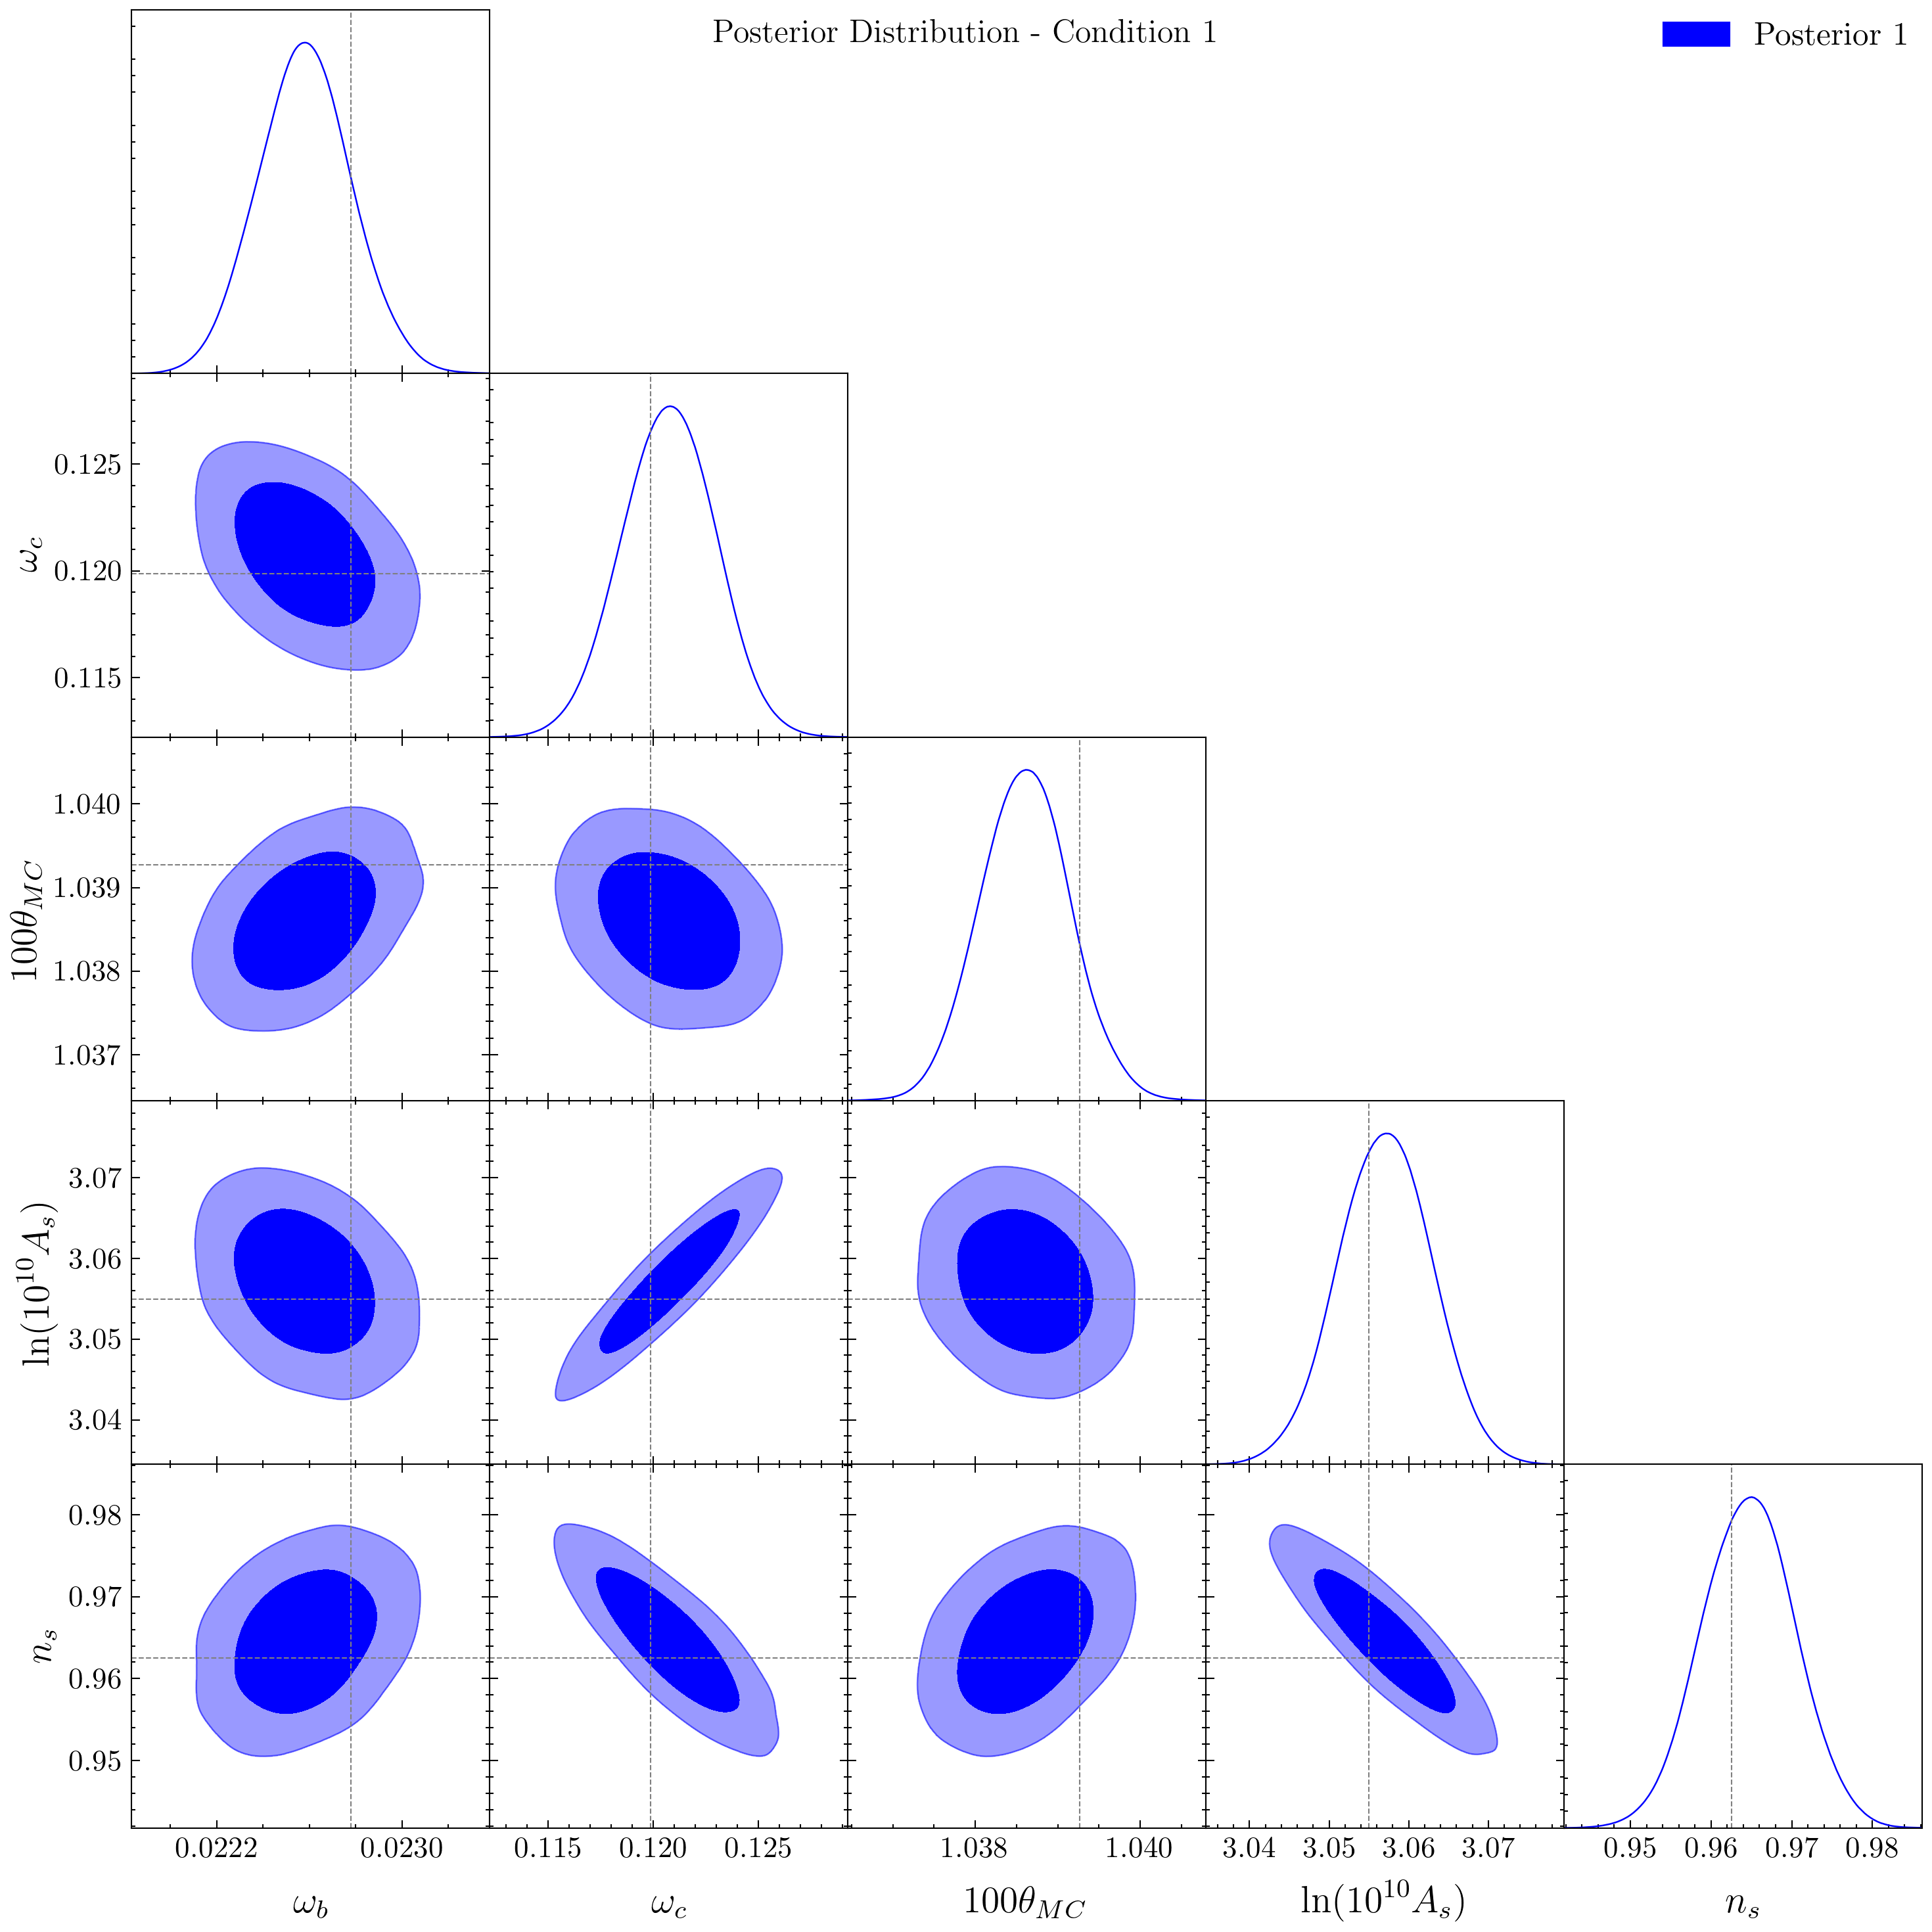


=== Posterior 2 ===
Valor verdadero: [0.02291545 0.12330841 1.039585   3.086858   0.9736042 ]
Media posterior: [[0.02274878 0.12234472 1.04067    3.085709   0.979217  ]
 [0.02260936 0.12451319 1.039401   3.088786   0.9733866 ]
 [0.0226881  0.12492055 1.039169   3.0913892  0.96791124]
 ...
 [0.02249758 0.12379826 1.0396637  3.0834575  0.9768193 ]
 [0.02292598 0.12389749 1.0391954  3.0912662  0.96814483]
 [0.02326038 0.12208443 1.0404143  3.0864391  0.98057485]]
Std posterior: [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


<Figure size 3000x3000 with 0 Axes>

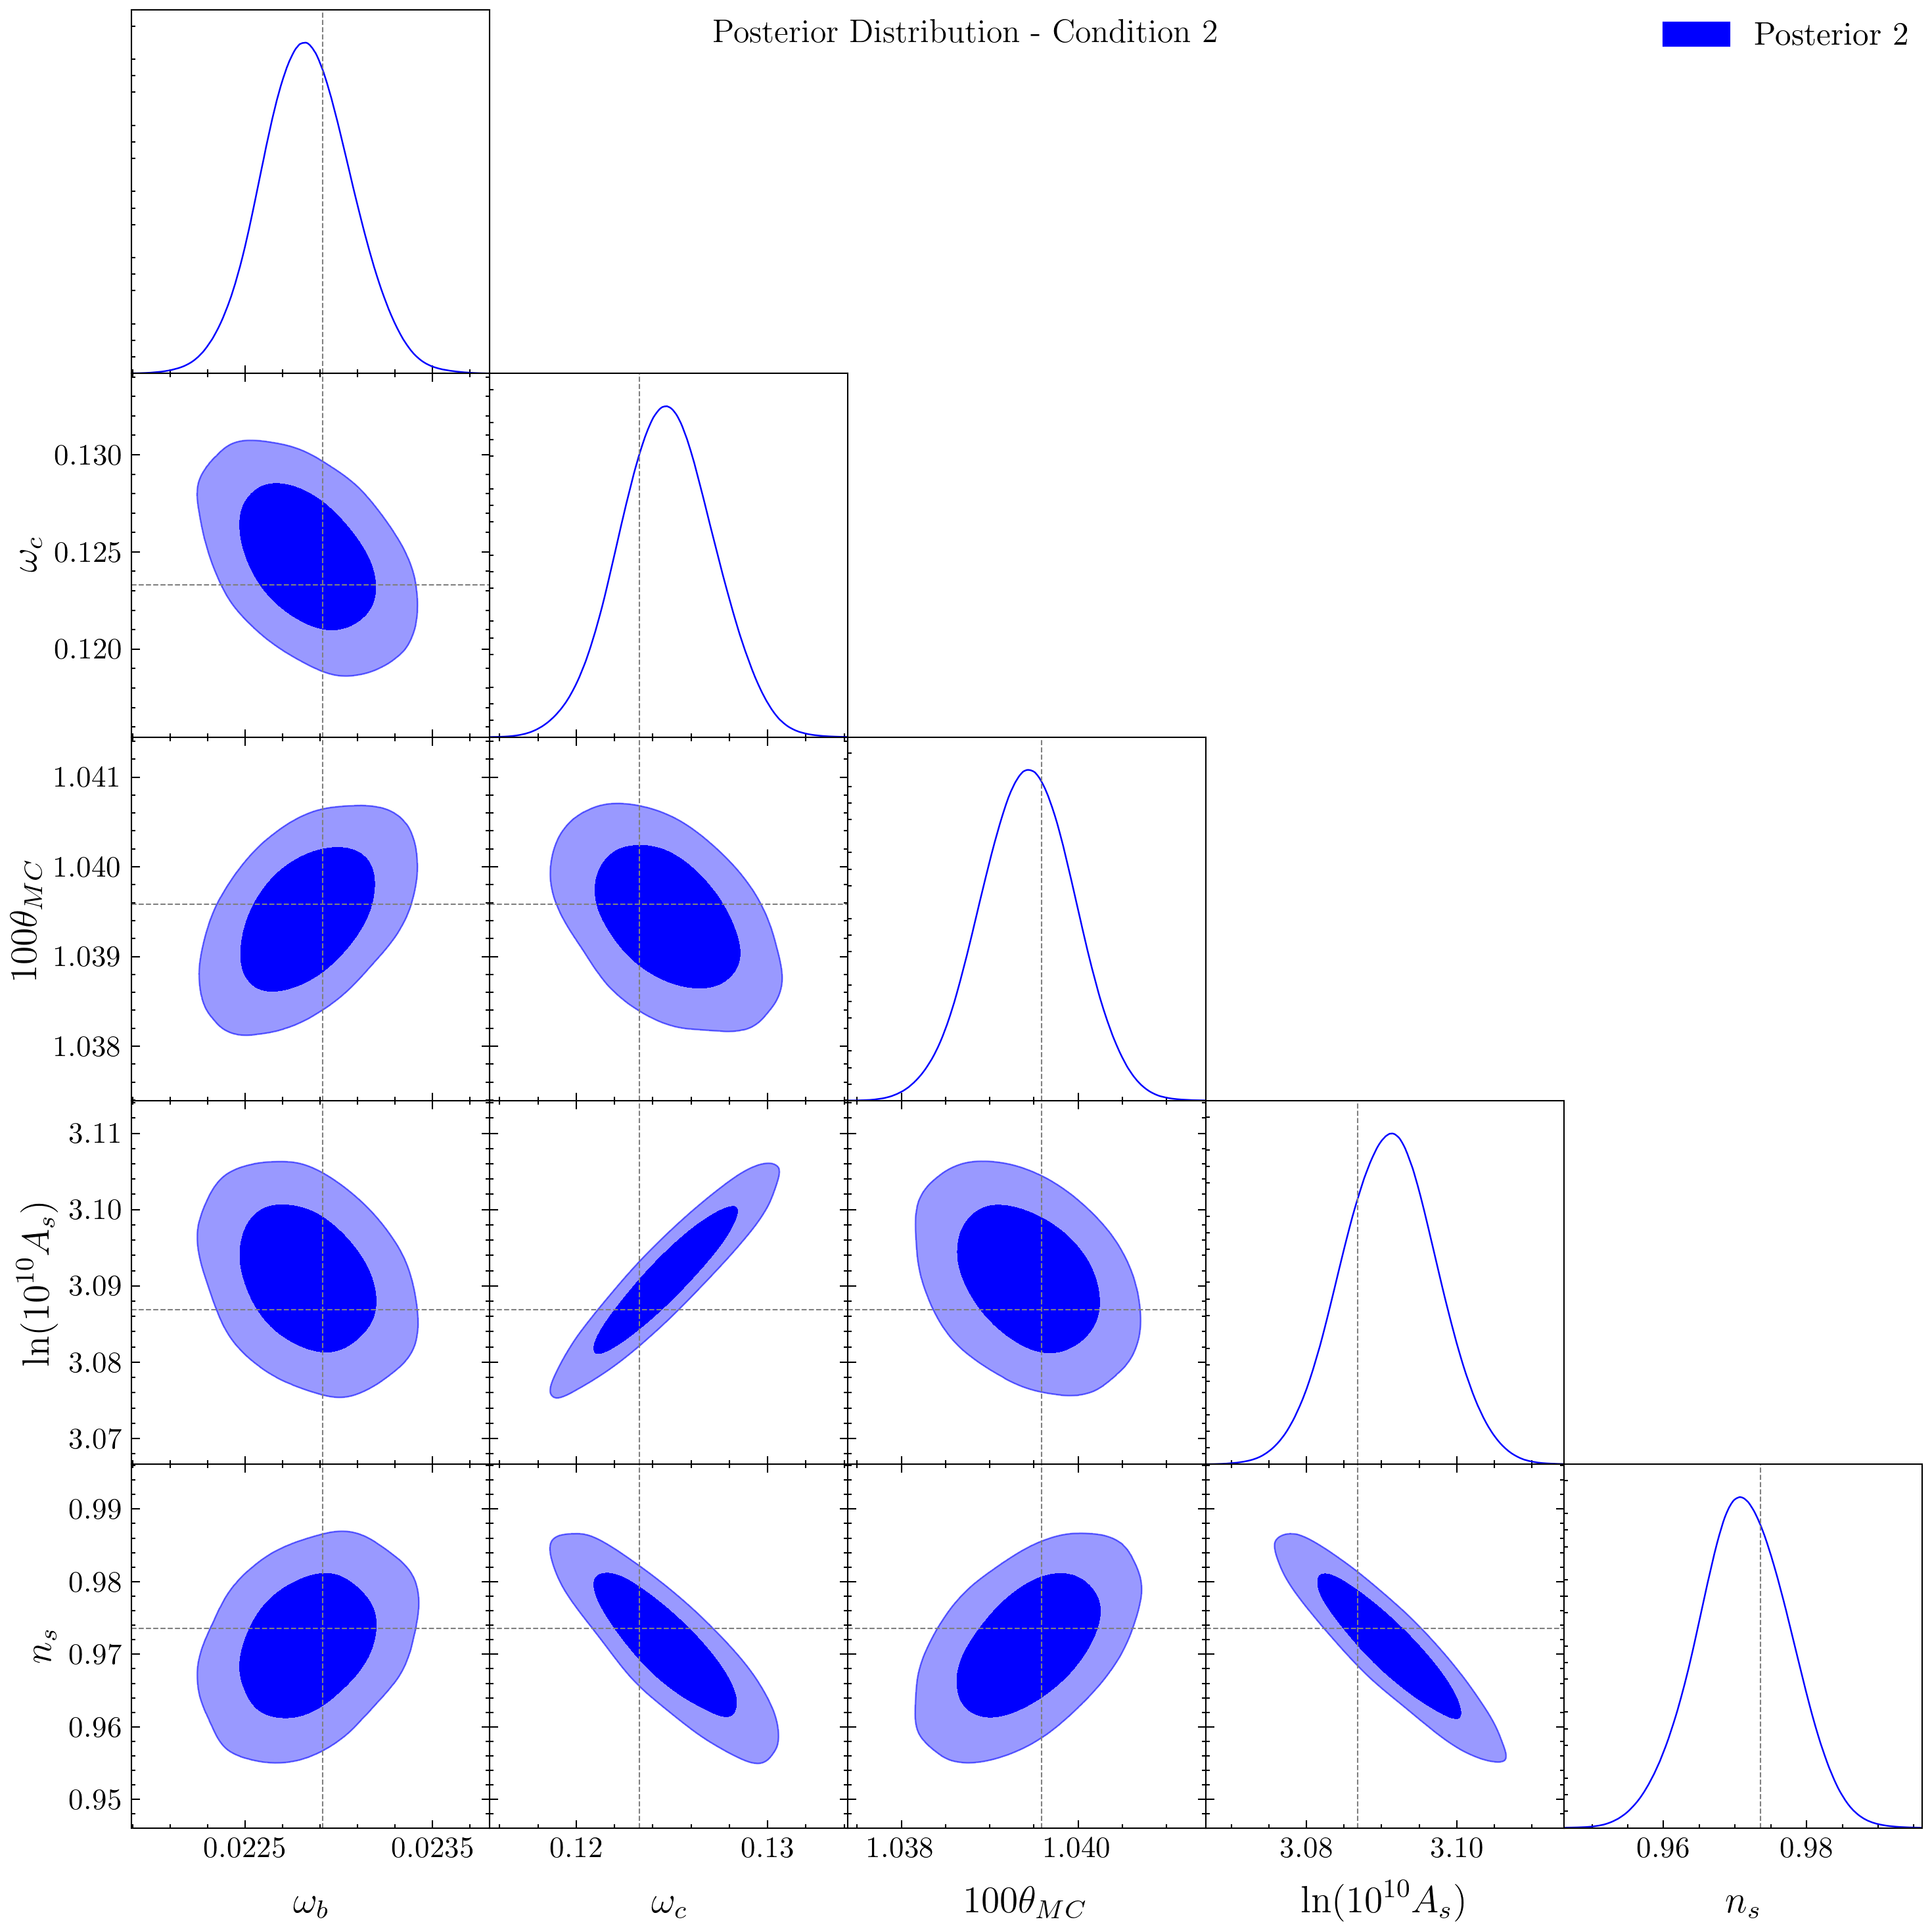


=== Posterior 3 ===
Valor verdadero: [0.02113375 0.12178016 1.0409149  3.0487225  0.93682915]
Media posterior: [[0.02109908 0.11782036 1.0422297  3.0401402  0.9503651 ]
 [0.02122931 0.11718132 1.0408391  3.0329804  0.95081186]
 [0.02131053 0.12098399 1.0417898  3.0434132  0.94364744]
 ...
 [0.02187467 0.11663415 1.0422506  3.037374   0.9455189 ]
 [0.02107015 0.12355972 1.0404707  3.0523467  0.9347578 ]
 [0.02121293 0.11845613 1.0406961  3.0375412  0.94271576]]
Std posterior: [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


<Figure size 3000x3000 with 0 Axes>

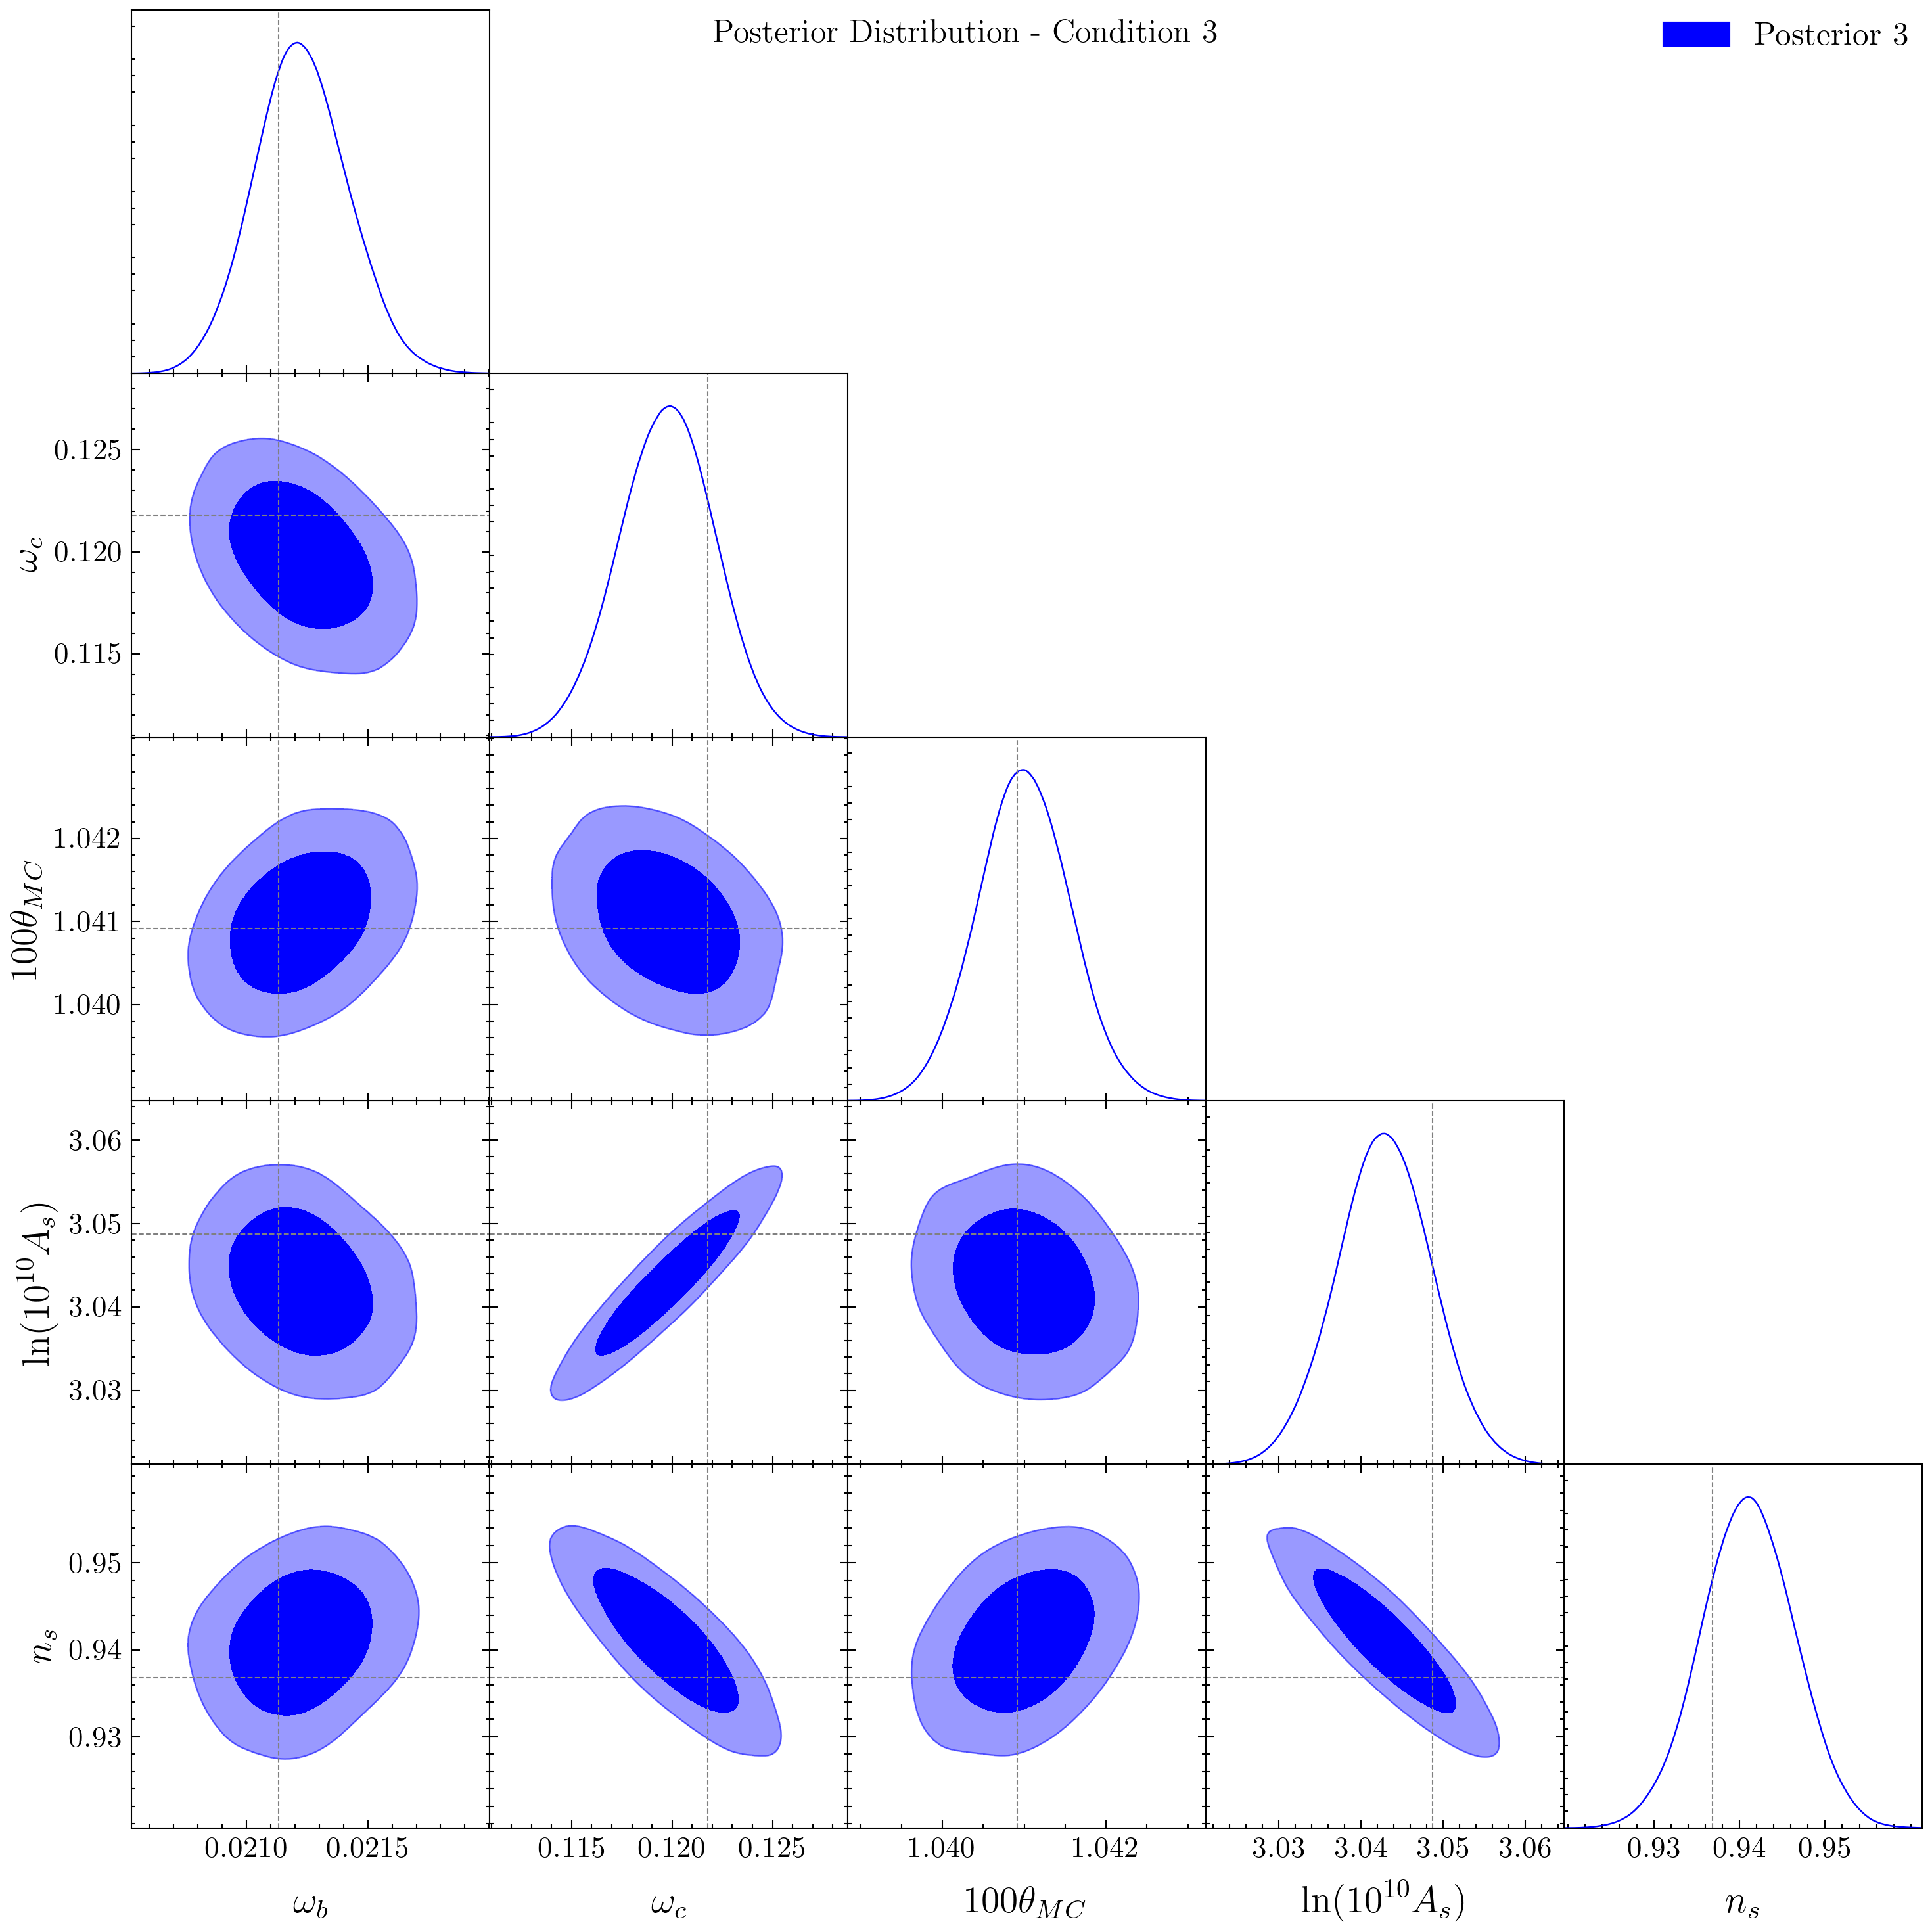

In [6]:
# function to sample from posterior given x condition (normalized)
def sample_posterior(x_condition, n_samples=25000):
    with torch.no_grad():
        samples = flow.sample(n_samples, context=x_condition.unsqueeze(0))
        samples_denorm = samples * theta_std + theta_mean
        return samples_denorm.numpy()
    
# we take 3 conditions from the data set for testing
# and plot the posterior for each (10000 samples)
n_test_conditions = 3
test_indices = torch.randperm(n_samples)[:n_test_conditions]
test_x = x_norm[test_indices]
test_theta_true = theta[test_indices]
param_names = ['omega_b', 'omega_c', 'theta_MC', 'ln10As', 'ns']
param_labels = [r'$\omega_b$', r'$\omega_c$', r'$100\theta_{MC}$', r'$\ln(10^{10}A_s)$', r'$n_s$']
for i in range(n_test_conditions):
    print(f"\n=== Posterior {i+1} ===")
    print(f"Valor verdadero: {test_theta_true[i].numpy()}")
    posterior_samples = sample_posterior(test_x[i], n_samples=10000)
    print(f"Media posterior: {posterior_samples.mean(axis=0)}")
    print(f"Std posterior: {posterior_samples.std(axis=0)}")
    plt.figure(figsize=(10, 10))
    plot_and_save_ppc(
        samples=[posterior_samples],
        true_parameter=test_theta_true[i].tolist(),
        param_names=param_names,
        param_labels=param_labels,
        sample_labels=[f'Posterior {i+1}'],
        title=f'Posterior Distribution - Condition {i+1}',
        sample_colors=['blue']
    )
    plt.show()